<a href="https://colab.research.google.com/github/Heet06/MLUP001/blob/main/Data_Visualization_using_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Visualization using Seaborn

##### Load Toyota dataset and import necessary libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/Toyota.csv", index_col = 0, na_values=['??', '????'])

df.dropna(inplace=True)

##### Data Preparation

Replacing Ambigous values with NaN and changing datatypes of columns for proper data interpretation.

In [2]:
df.head()

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986.0,Diesel,90.0,1.0,0,2000,three,1165
1,13750,23.0,72937.0,Diesel,90.0,1.0,0,2000,3,1165
3,14950,26.0,48000.0,Diesel,90.0,0.0,0,2000,3,1165
4,13750,30.0,38500.0,Diesel,90.0,0.0,0,2000,3,1170
5,12950,32.0,61000.0,Diesel,90.0,0.0,0,2000,3,1170


In [3]:
df["Doors"] = df["Doors"].replace(
    {"three": 3, "four": 4, "five": 5}
).astype(int)

df['Automatic'] = df['Automatic'].astype('category')
df['MetColor'] = df['MetColor'].astype('category')

In [4]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Price      1096 non-null   int64   
 1   Age        1096 non-null   float64 
 2   KM         1096 non-null   float64 
 3   FuelType   1096 non-null   object  
 4   HP         1096 non-null   float64 
 5   MetColor   1096 non-null   category
 6   Automatic  1096 non-null   category
 7   CC         1096 non-null   int64   
 8   Doors      1096 non-null   int64   
 9   Weight     1096 non-null   int64   
dtypes: category(2), float64(3), int64(4), object(1)
memory usage: 79.4+ KB
None
   Price   Age       KM FuelType    HP MetColor Automatic    CC  Doors  Weight
0  13500  23.0  46986.0   Diesel  90.0      1.0         0  2000      3    1165
1  13750  23.0  72937.0   Diesel  90.0      1.0         0  2000      3    1165
3  14950  26.0  48000.0   Diesel  90.0      0.0         0  2000      3    1165
4  13750 

##### Regression Scatter Plot

**What is it?**
- Scatter plot with regression  line.

**When/Where to Use?**
- To see relationship and trend estimation.

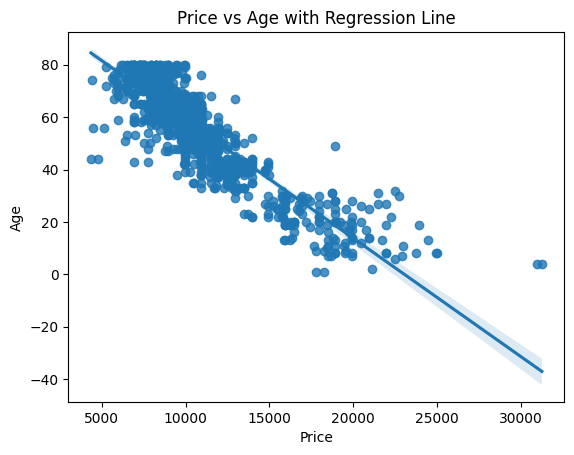

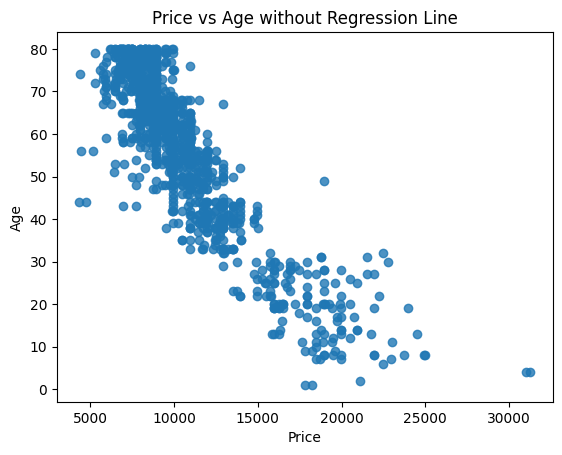

In [5]:
sns.regplot(x='Price', y='Age', data=df)
plt.title("Price vs Age with Regression Line")
plt.show()

sns.regplot(x='Price', y='Age', data=df, fit_reg=False)
plt.title('Price vs Age without Regression Line')
plt.show()

**Inference**
- Strong negative correlation between Age and Price.
- The regression line quantifies this trend, helping to estimate price depreciation with age, providing a better model for prediction of price from age.

##### Lmplot with Hue

**What is it?**
- Scatter plot with categories highlighted by color.

**When/Where to use?**
- Best for comparing groups in relationships.

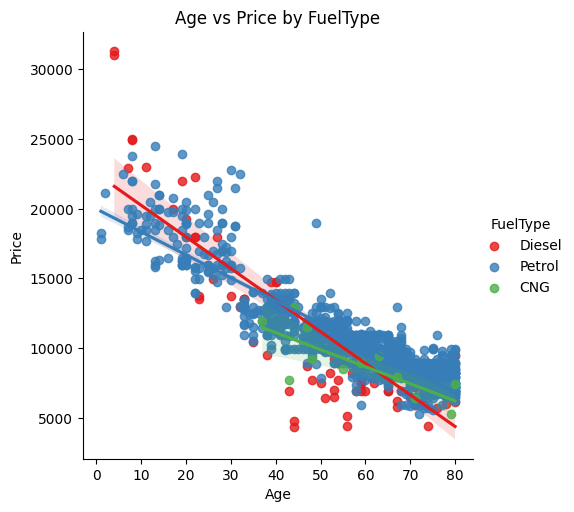

In [6]:
sns.lmplot(x='Age', y='Price', data=df, hue='FuelType', fit_reg=True, palette='Set1')
plt.title('Age vs Price by FuelType')
plt.show()

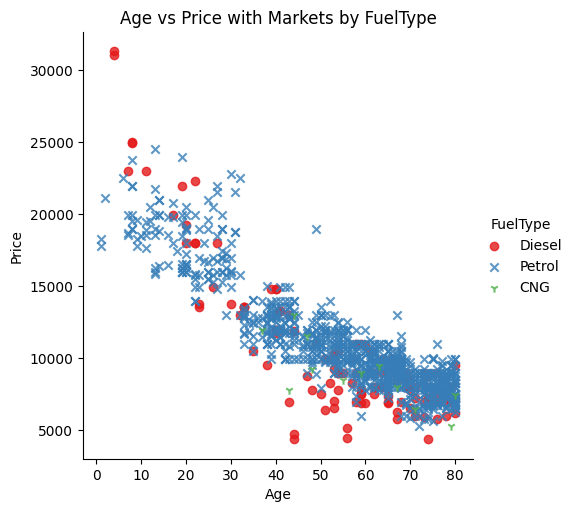

In [7]:
sns.lmplot(x='Age', y='Price', data=df, hue='FuelType', fit_reg=False, markers=['o', 'x','1'], palette='Set1')
plt.title('Age vs Price with Markets by FuelType')
plt.show()

**Inference**
- By adding FuelType as hue, we see the depreciation trend across categories. Petrol, Diesel and CNG vehicles asll show decreasing price with age, but the spread and clustering reveal subtle differences in their resale value trends.

##### Count Plot

**What is it?**
- Bar plot showing count of categories

**When/Where to use?**
- Best for categorical frequency

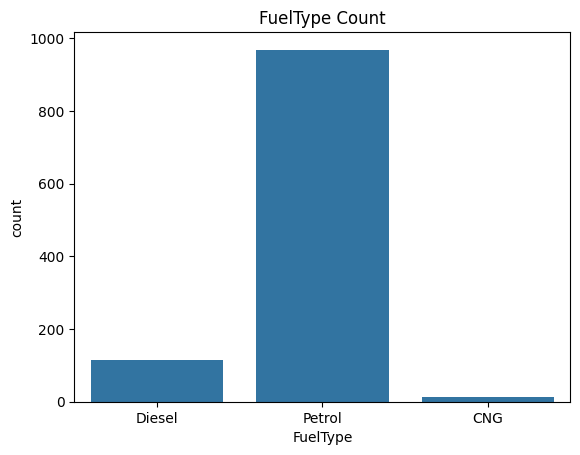

In [8]:
sns.countplot(x='FuelType', data=df)
plt.title('FuelType Count')
plt.show()

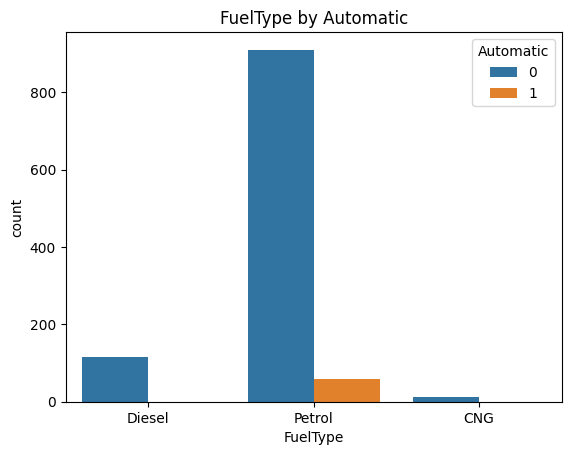

In [9]:
sns.countplot(x='FuelType', hue='Automatic', data=df)
plt.title('FuelType by Automatic')
plt.show()

**Inference**
- The count plot again confirms that Petrol cars dominate. The grouped version with Automatic shows that most Petrol cars are manual, revealing transmission preferences tied to fuel type.

##### Histogram with Seaboarn

**What is it?**
- Shows distribution, optionally with density curve.

**When/Where to use?**
- For exploring numerical variable shape.

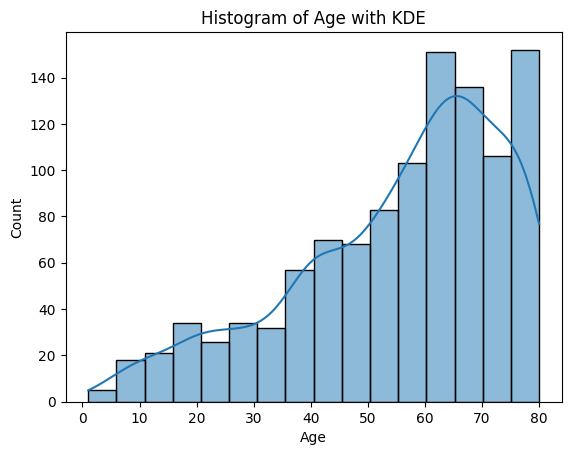

In [10]:
sns.histplot(df['Age'], kde=True)
plt.title('Histogram of Age with KDE')
plt.show()

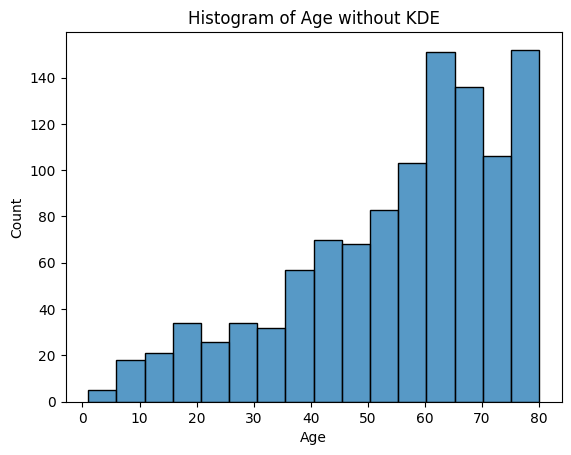

In [11]:
sns.histplot(df['Age'], kde=False)
plt.title('Histogram of Age without KDE')
plt.show()

**Inference**
- The histogram of Age show a peak at older ages. The KDE curve visualizes this skew clearly.

Boxplots

**What is it?**
- Shows median, quartiles, and outliers.

**When/Where to use?**
- Best for comparing distributions.

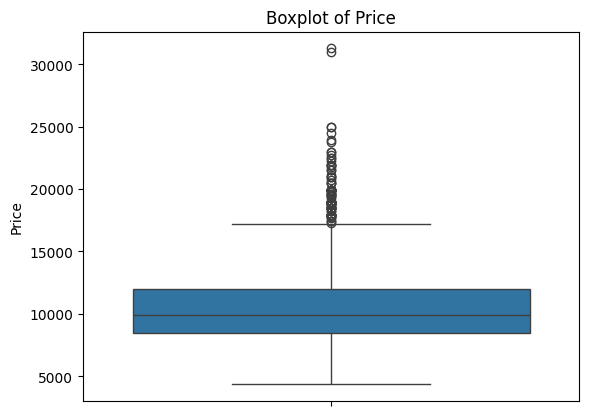

In [12]:
sns.boxplot(y='Price', data=df)
plt.title('Boxplot of Price')
plt.show()

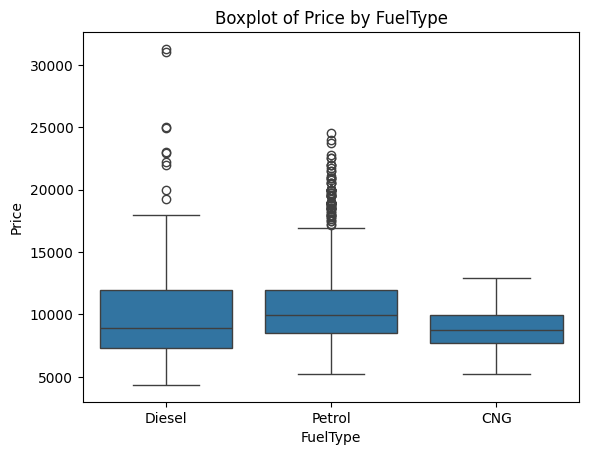

In [13]:
sns.boxplot(x='FuelType', y='Price', data=df)
plt.title('Boxplot of Price by FuelType')
plt.show()

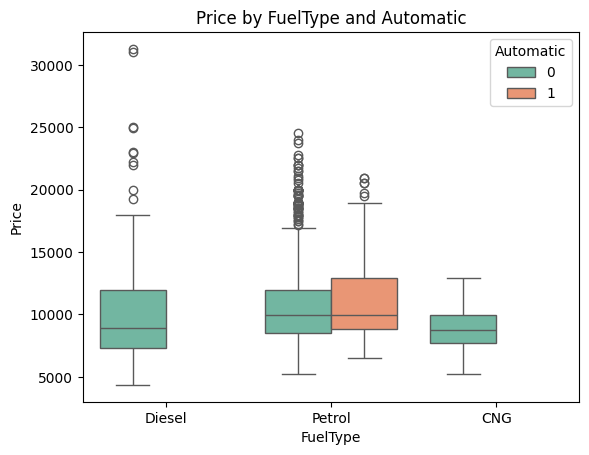

In [14]:
sns.boxplot(x='FuelType', y='Price', hue='Automatic', data=df, palette='Set2')
plt.title('Price by FuelType and Automatic')
plt.show()

**Inference**
- Petrol cars have highest median price.
- Despite diesel cars having few higher outlier has lower median price than that of petrol.

##### Combined Boxplot and Histogram

**What is it?**
- Boxplot + Histogram of shared axis.

**When/Where to use?**
- Shows summary + distribution together.

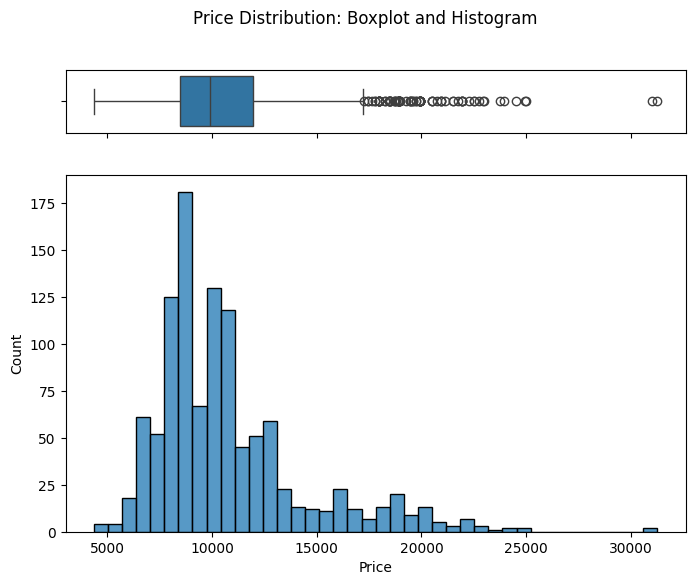

In [15]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True,
                                    gridspec_kw={"height_ratios": (.15, .85)},
                                    figsize=(8, 6)
)
sns.boxplot(x=df['Price'], ax=ax_box)
sns.histplot(df['Price'], kde=False, ax=ax_hist)
ax_box.set(xlabel='')
plt.suptitle('Price Distribution: Boxplot and Histogram')
plt.show()

##### Heatmap

**What is it?**
- Visualize correlation matrix.

**When/Where to use?**
- Best for finding relationships among numeric variables.

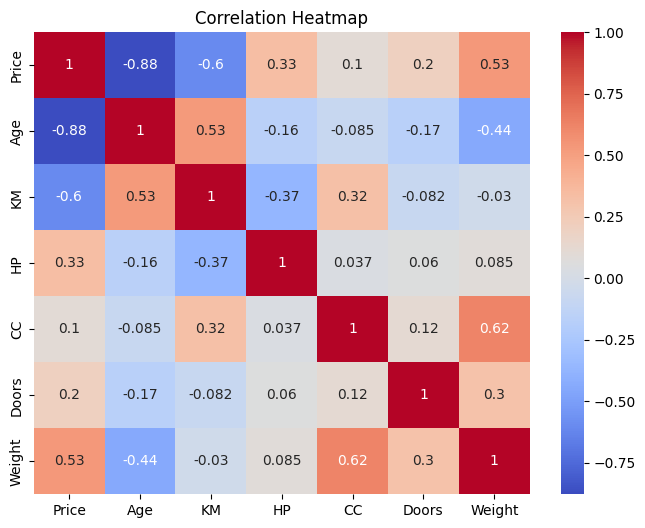

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Inference**
- The heatmap shows strong negative correlation between Age and Price. KM also has mild negative correlation with Price, while other variables show weaker relationships.

##### Pairplot

**What is it?**
- Matrix of scatterplots for all numeric variable pairs.

**When/Where to use?**
- Best for exploring multiple relationships at once.

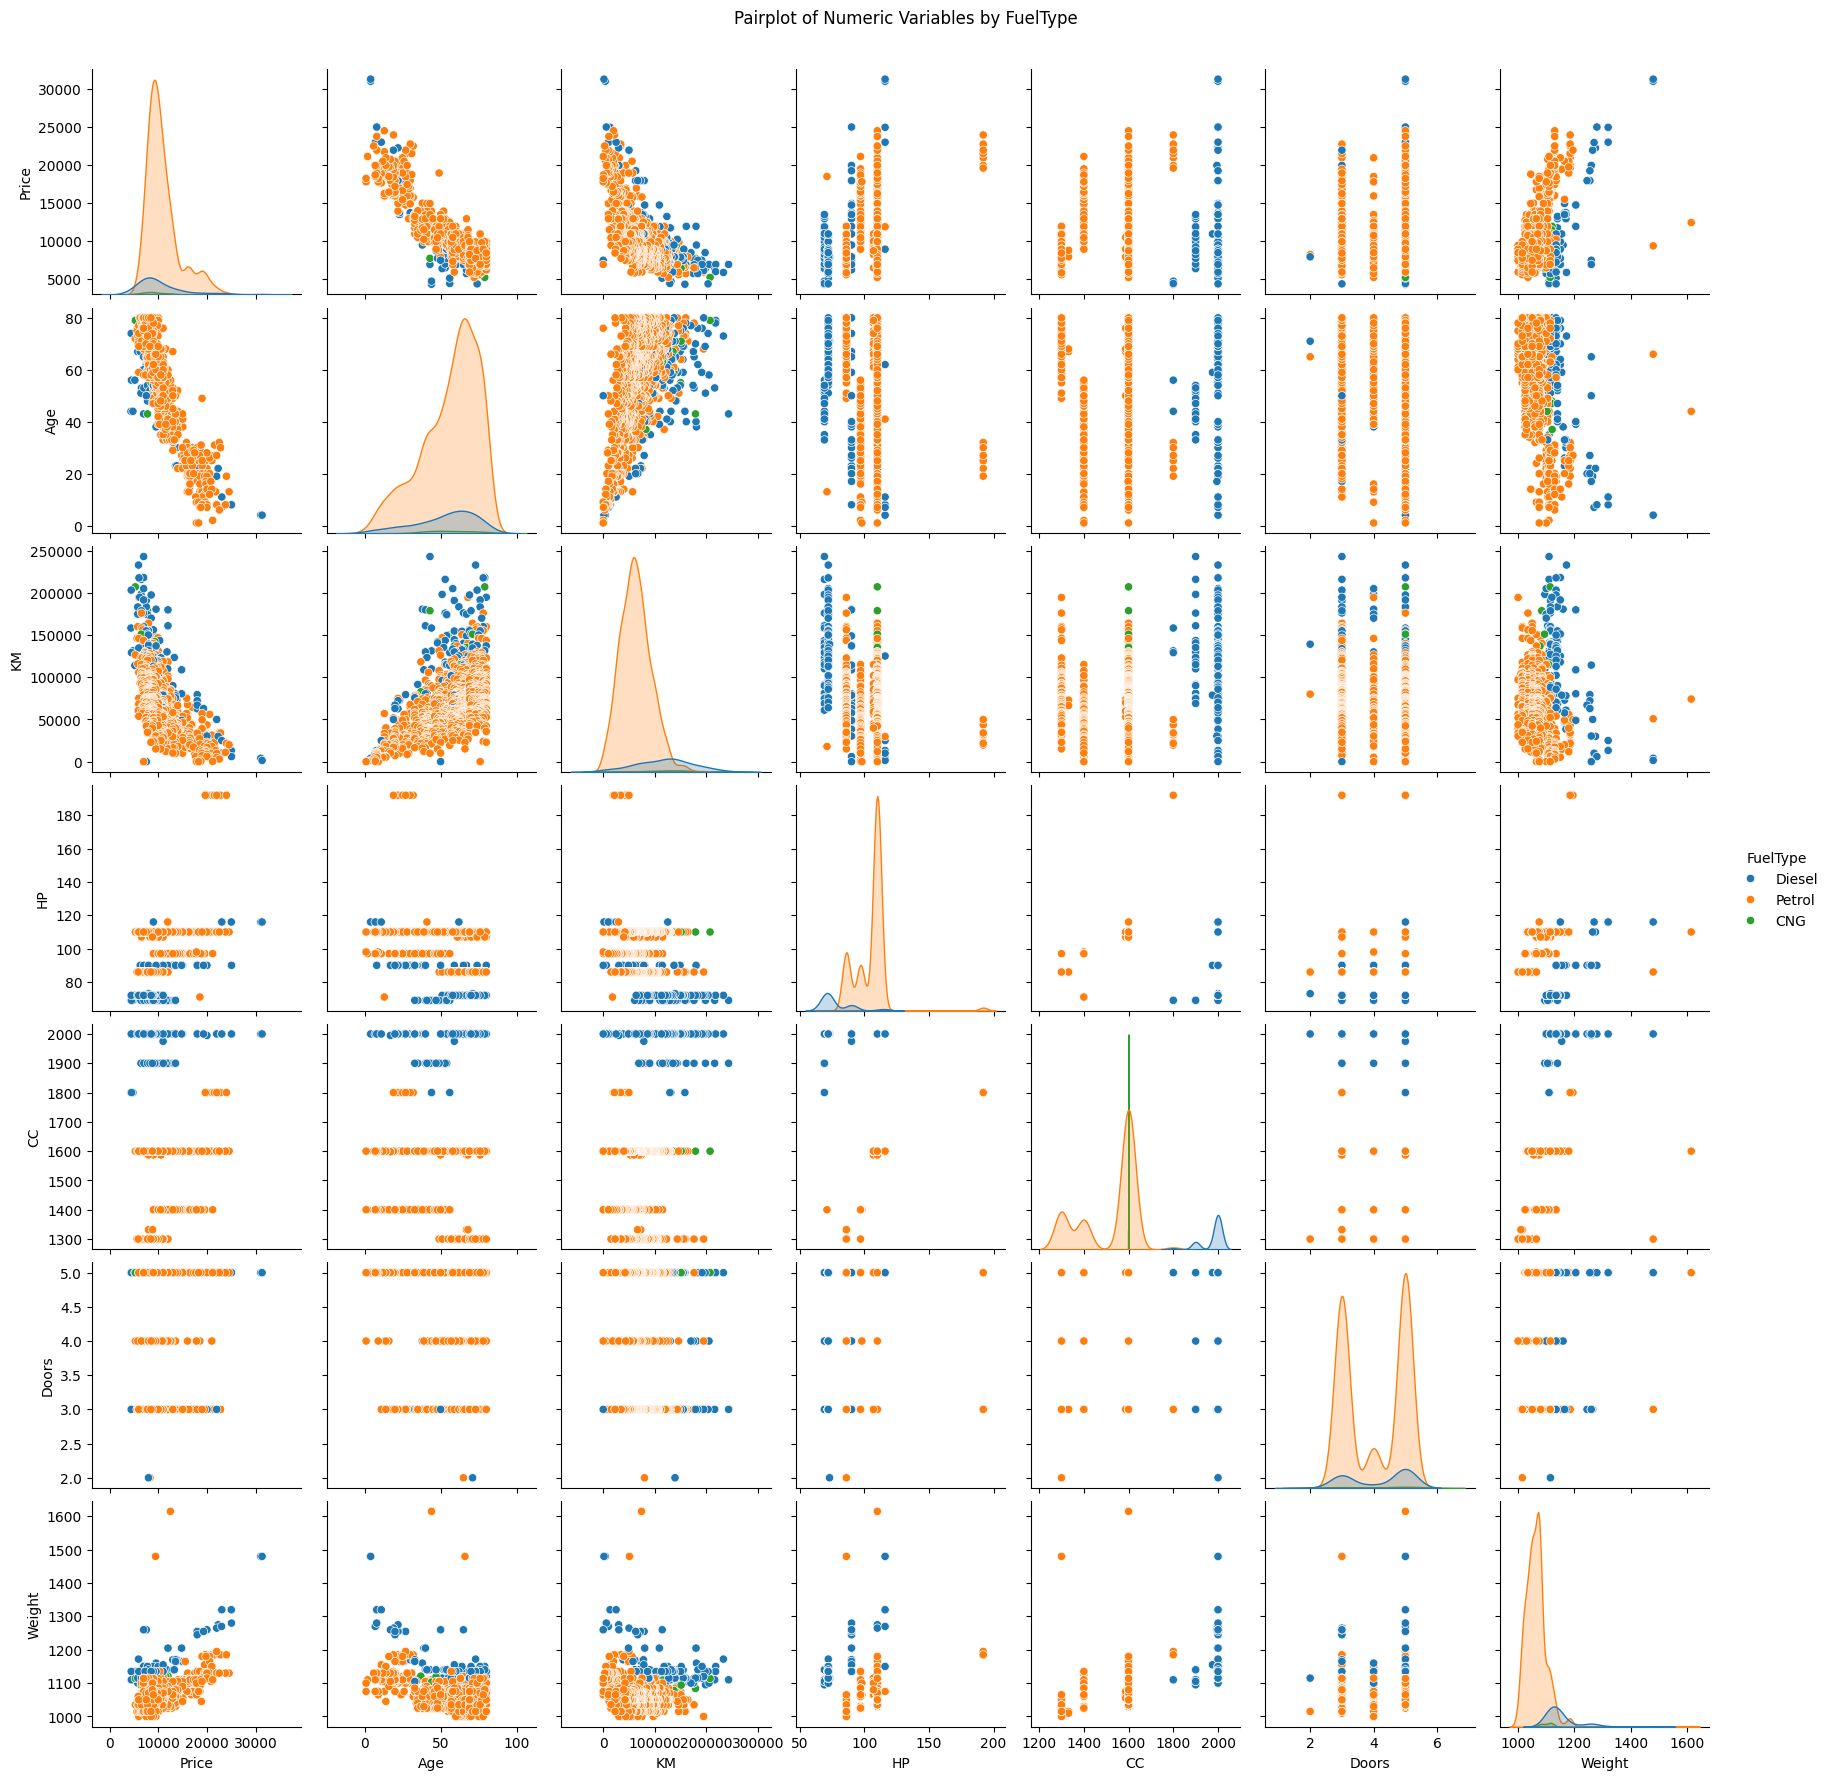

In [17]:
sns.pairplot(df, hue='FuelType')
plt.suptitle('Pairplot of Numeric Variables by FuelType', y=1.02)
plt.show()

**Inference**
- The pairplot reveals clear negative trends between Age and Price, and KM and Price. Color-coding by FuelType shows these trends hold across categories, supporting consitent depreciation patterns.

**Key Takeaways from the Toyota Data:**
- **Depreciation Trend:** Clear negative relationship between Age and Price.
- **FuelType Dominance:** Petrol cars make up most of the dataset.
- **KM driven Distribution:** Most vehicles have moderate KM, with a right-skewed distribution.
- **Transmission Patterns:** Manual dominates but varies by FuelType.
- **Price Outliers:** Boxplots show right-skew and multiple outliers, emphasizing price variation.